# Part 4 — Teaching the Model: How Training Actually Works

## Think of it as coaching a student 🎓

In Parts 1-3 we *built* the model — the brain. But a fresh brain knows nothing. Part 4 is about **teaching** it, and teaching always looks the same whether it's a person or a model:

> A student practices on **flashcards** ("here's a phrase — what word comes next?"), checks each guess against the answer, and makes a **small correction** each time they're wrong. Do that millions of times and they get good. A good coach starts the corrections **gently**, pushes harder in the middle, eases off near the end, **saves the student's progress** so a sick day doesn't lose everything, and keeps a **progress chart** on the wall.

That's the entire Part 4 training loop. Every piece below is one part of good coaching:

| Coaching a student | Training the model | Section |
|---|---|---|
| reading in *chunks*, not letter-by-letter | **BPE tokenizer** | 4.1 |
| flashcards: "guess the next word" | **dataset (x, y) pairs** | 4.1 |
| how big a correction to make, and when | **learning-rate schedule** | 4.2 |
| fast rough mental math (without losing tiny numbers) | **mixed precision (AMP)** | 4.3 |
| review a few cards before updating your notes | **gradient accumulation** | 4.3 |
| save your progress so you can resume | **checkpointing** | 4.4 |
| a progress chart on the wall | **logging** | 4.5 |
| the full daily practice routine | **training loop** | 4.6 |
| the exam — write on your own | **sampling** | 4.7 |

**What this part is:** we take the finished Part 3 model and actually *coach* it. By the end, every line of `train.py` will read like common sense.

**What you should know going in:**
- Parts 1-3 (the model itself) are fresh
- You're comfortable with PyTorch tensors and the idea of an optimizer nudging weights

**We use one tiny practice text the whole way through:**
> `"i love deep learning. i love coding. coding is deep learning."`


## The Map

One "study session" repeats over and over: grab some flashcards, let the model guess, measure how wrong it was, make a correction, jot it on the progress chart, save the progress, repeat. The diagram below is that loop. You'll see it at the top of every section with the current step lit up in green and the rest greyed out, so you always know where you are.

```mermaid
graph TD
    raw["raw text file<br>(tiny.txt)"]
    bpe["4.1 BPE Tokenizer<br>train + encode/decode"]
    ds["4.1 Dataset / DataLoader<br>(x, y) shifted batches"]
    fwd["forward: GPTModern (Part 3)"]
    loss["CE loss"]
    amp["4.3 AMP + grad accum<br>scaled backward"]
    opt["AdamW step<br>(β = 0.9, 0.95; wd = 0.1)"]
    sched["4.2 Warmup + Cosine LR"]
    log["4.5 Logger<br>(TB / wandb / noop)"]
    ckpt["4.4 Checkpoint<br>model + opt + sched + scaler + step + cfg"]

    raw --> bpe --> ds --> fwd --> loss --> amp --> opt --> sched --> log --> ckpt
    ckpt -. next batch .-> fwd

    style raw fill:#e8e8e8,stroke:#bbb,color:#777
    style bpe fill:#e8e8e8,stroke:#bbb,color:#777
    style ds fill:#e8e8e8,stroke:#bbb,color:#777
    style fwd fill:#e8e8e8,stroke:#bbb,color:#777
    style loss fill:#e8e8e8,stroke:#bbb,color:#777
    style amp fill:#e8e8e8,stroke:#bbb,color:#777
    style opt fill:#e8e8e8,stroke:#bbb,color:#777
    style sched fill:#e8e8e8,stroke:#bbb,color:#777
    style log fill:#e8e8e8,stroke:#bbb,color:#777
    style ckpt fill:#e8e8e8,stroke:#bbb,color:#777
```

Reading the loop once around: take the **raw text** → chop it into chunks (**BPE**) → make flashcards (**dataset**) → the model **guesses** the next word → measure how wrong (**loss**) → work out the correction carefully (**AMP**) → **nudge the weights** (AdamW) → adjust the step size (**schedule**) → update the **progress chart** (logger) → **save progress** (checkpoint) → back for the next batch.

**Part 2 already did a baby version of this. Part 4 upgrades every step to how real training is done:**

| Part 2 (toy version) | Part 4 (the real thing) | Section |
|---|---|---|
| read letter-by-letter (vocab 256) | **read in chunks** (BPE, vocab 8k-32k) | 4.1 |
| same correction size always | **gentle → bold → gentle** schedule | 4.2 |
| slow, precise arithmetic | **fast rough arithmetic** (AMP) | 4.3 |
| one batch at a time | **review several, then update** (accumulation) | 4.3 |
| no way to resume | **save & resume** exactly where you stopped | 4.4 |
| `print()` the loss | a **live progress chart** | 4.5 |
| a bare loop | a robust loop you can safely **Ctrl-C** | 4.6 |
| — | **take the exam** from a saved model | 4.7 |


## Setup

Run this cell once. It adds `part_4/` to the path so we can `import` from its modules and the Part 3 model.


In [1]:
import sys, pathlib

# This notebook lives inside part_4/. Add it and part_3/ (for GPTModern) to sys.path.
NB_DIR = pathlib.Path().resolve()
PART_3 = NB_DIR.parent / "part_3"
for p in (str(NB_DIR), str(PART_3)):
    if p not in sys.path:
        sys.path.insert(0, p)

import math, time, json, tempfile, shutil
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

torch.manual_seed(0)
np.random.seed(0)
np.set_printoptions(precision=3, suppress=True)

# The anchor text we reuse across sections
ANCHOR = "i love deep learning. i love coding. coding is deep learning."
print(f"Setup complete. Working directory: {NB_DIR}")
print(f"ANCHOR ({len(ANCHOR)} chars): {ANCHOR}")


Setup complete. Working directory: C:\Home\Projects\DataScienceLearningProjects\15. Build LLM From Scratch\part_4
ANCHOR (61 chars): i love deep learning. i love coding. coding is deep learning.


---
## 4.1 Reading in Chunks (the BPE Tokenizer)

```mermaid
graph TD
    raw["raw text file<br>(tiny.txt)"]
    bpe["4.1 BPE Tokenizer<br>train + encode/decode"]
    ds["4.1 Dataset / DataLoader<br>(x, y) shifted batches"]
    fwd["forward: GPTModern (Part 3)"]
    loss["CE loss"]
    amp["4.3 AMP + grad accum<br>scaled backward"]
    opt["AdamW step<br>(β = 0.9, 0.95; wd = 0.1)"]
    sched["4.2 Warmup + Cosine LR"]
    log["4.5 Logger<br>(TB / wandb / noop)"]
    ckpt["4.4 Checkpoint<br>model + opt + sched + scaler + step + cfg"]

    raw --> bpe --> ds --> fwd --> loss --> amp --> opt --> sched --> log --> ckpt
    ckpt -. next batch .-> fwd

    style raw fill:#e8e8e8,stroke:#bbb,color:#777
    style bpe fill:#d5f5e3,stroke:#28a745,stroke-width:3px,color:#000
    style ds fill:#e8e8e8,stroke:#bbb,color:#777
    style fwd fill:#e8e8e8,stroke:#bbb,color:#777
    style loss fill:#e8e8e8,stroke:#bbb,color:#777
    style amp fill:#e8e8e8,stroke:#bbb,color:#777
    style opt fill:#e8e8e8,stroke:#bbb,color:#777
    style sched fill:#e8e8e8,stroke:#bbb,color:#777
    style log fill:#e8e8e8,stroke:#bbb,color:#777
    style ckpt fill:#e8e8e8,stroke:#bbb,color:#777
```

### What we're doing here, and why

A model can't read letters — it reads *numbers*. So first we have to chop text into pieces and give each piece an ID number. **How big should the pieces be?**

In Parts 2-3 we used the simplest possible chopping: **one piece per byte** (basically one per letter). It works, but it's like a child sounding out *every single letter* — "l-e-a-r-n-i-n-g" is 8 separate pieces. The model wastes most of its limited attention span just re-assembling words.

A fluent reader doesn't do that. They recognize whole common words at a glance ("learning") and only sound out rare ones. **BPE (Byte Pair Encoding) teaches the tokenizer to read like a fluent reader.** The recipe is simple:

> Look at the text, find the **two pieces that sit next to each other most often**, and glue them into one new piece. Repeat until you have as many pieces as you wanted.

So `l`+`e` → `le`, then `le`+`a` → `lea`, and so on, until frequent whole words like "learning" and "coding" each become a *single* piece. The payoff: the same sentence takes **3-5× fewer pieces**, so 3-5× more actual text fits in the model's view.

### The formula behind it (optional)

At each step, pick the most frequent neighboring pair and merge it:

$$\text{best pair} = \arg\max_{(a,b)} \;\#\{(a,b)\text{ sitting next to each other in the text}\}$$

When we save the tokenizer, we get a few files — you don't need to memorize them, just know what they're for:

| File | What it holds |
|---|---|
| `vocab.json` | the list of pieces and their ID numbers |
| `merges.txt` | the glue-these-together rules, in the order learned |
| `tokenizer.json` | the whole tokenizer in one file (used to reload it) |
| `bpe_meta.json` | small notes (vocabulary size, special tokens) |

### Let's train one on our practice text


In [2]:
# Write the anchor text repeated 200x to a temp file so BPE has enough signal to find merges.
tmp = tempfile.mkdtemp()
data_path = pathlib.Path(tmp) / "anchor.txt"
data_path.write_text((ANCHOR + "\n") * 200, encoding="utf-8")
print(f"Wrote {data_path.stat().st_size} bytes of training text.")

# Train a tiny BPE
# NOTE: ByteLevelBPETokenizer starts with the 256-byte alphabet + special tokens (~261).
# vocab_size must exceed that to actually learn merges. 500 is plenty for our tiny demo.
try:
    from tokenizer_bpe import BPETokenizer
    tok = BPETokenizer(vocab_size=500)
    tok.train(str(data_path))
    tok_dir = pathlib.Path(tmp) / "tok"
    tok.save(str(tok_dir))
    print(f"\nSaved tokenizer to {tok_dir}")
    print("Files written:", sorted(p.name for p in tok_dir.iterdir()))
except ImportError as e:
    print("`tokenizers` package not installed. Run `pip install tokenizers` and re-run this cell.")
    raise


Wrote 12600 bytes of training text.

Saved tokenizer to C:\Users\MSI\AppData\Local\Temp\tmp0c8dt2o8\tok
Files written: ['bpe_meta.json', 'merges.txt', 'tokenizer.json', 'vocab.json']


### Chunks vs letters — count the difference

Let's tokenize the same sentence both ways and count the pieces. Fewer pieces = more room for actual content in the model's limited view.


In [3]:
# Byte tokenizer (Part 2/3): one ID per UTF-8 byte
byte_ids = list(ANCHOR.encode("utf-8"))
bpe_ids  = tok.encode(ANCHOR)

print(f"text                 : {ANCHOR!r}")
print(f"byte tokenization    : {len(byte_ids):3d} ids  e.g. {byte_ids[:12]} ...")
print(f"BPE tokenization     : {len(bpe_ids):3d} ids  e.g. {bpe_ids[:12]} ...")
print(f"compression factor   : {len(byte_ids) / len(bpe_ids):.2f}x")
print()
print(f"BPE decode round-trip: {tok.decode(bpe_ids)!r}")


text                 : 'i love deep learning. i love coding. coding is deep learning.'
byte tokenization    :  61 ids  e.g. [105, 32, 108, 111, 118, 101, 32, 100, 101, 101, 112, 32] ...
BPE tokenization     :  14 ids  e.g. [77, 280, 278, 279, 18, 272, 280, 277, 18, 277, 282, 278] ...
compression factor   : 4.36x

BPE decode round-trip: 'i love deep learning. i love coding. coding is deep learning.'


### Peek at the glue-rules it learned

Here are the first 20 "glue these two pieces together" rules, in the order BPE learned them. The earliest ones are the most common pairs in our text.


In [4]:
merges_file = tok_dir / "merges.txt"
lines = merges_file.read_text(encoding="utf-8").splitlines()
print(f"Total merges learned: {len(lines)-1}")  # first line is a header
print()
print("First 20 merges (most frequent pairs):")
for i, line in enumerate(lines[1:21]):
    print(f"  {i+1:2d}. {line}")


Total merges learned: 22

First 20 merges (most frequent pairs):
   1. i n
   2. Ġ l
   3. in g
   4. a r
   5. c o
   6. d e
   7. d ing
   8. e p
   9. e ar
  10. n ing
  11. o v
  12. Ġ i
  13. Ġ co
  14. Ġ de
  15. Ġl ear
  16. Ġl ov
  17. Ġco ding
  18. Ġde ep
  19. Ġlear ning
  20. Ġlov e


**What you see:** the first rules glue together very common pairs like `i n`, `e d`, `e r` — the building blocks that let "learning" and "coding" eventually become single pieces.

### What does each piece actually say?

Every ID stands for a chunk of text. Let's decode them one at a time to see the actual chunks our sentence got broken into.


In [5]:
print(f"BPE tokens for: {ANCHOR!r}\n")
for tid in bpe_ids[:25]:
    piece = tok.decode([tid])
    print(f"  id {tid:4d}  ->  {piece!r}")


BPE tokens for: 'i love deep learning. i love coding. coding is deep learning.'

  id   77  ->  'i'
  id  280  ->  ' love'
  id  278  ->  ' deep'
  id  279  ->  ' learning'
  id   18  ->  '.'
  id  272  ->  ' i'
  id  280  ->  ' love'
  id  277  ->  ' coding'
  id   18  ->  '.'
  id  277  ->  ' coding'
  id  282  ->  ' is'
  id  278  ->  ' deep'
  id  279  ->  ' learning'
  id   18  ->  '.'


### Shape trace

| Stage | Shape / Type |
|---|---|
| `text` | `str` of length `N_chars` |
| `text.encode("utf-8")` | `bytes` of length `N_bytes ≥ N_chars` |
| `tok.encode(text)` | `list[int]` of length `N_tokens ≪ N_bytes` |
| `tok.decode(ids)` | `str` (round-trip) |

### Why bother with chunks? (simple to deep)

- **Simple:** fewer pieces per sentence → more real text fits in the model's limited view at once.
- **Practical:** the model gets to learn the word "love" *once*, as its own thing — instead of re-learning how to assemble it from `l`, `o`, `v`, `e` every single time it appears.
- **Deeper:** chunking is really just *compression* — packing the same meaning into fewer, more meaningful pieces. The less the model has to spend on spelling, the more it can spend on meaning.

**In one line:** reading in chunks is a free upgrade — same text, far fewer pieces, much more context.


---
## 4.1 (continued) — Making Flashcards (the Dataset)

```mermaid
graph TD
    raw["raw text file<br>(tiny.txt)"]
    bpe["4.1 BPE Tokenizer<br>train + encode/decode"]
    ds["4.1 Dataset / DataLoader<br>(x, y) shifted batches"]
    fwd["forward: GPTModern (Part 3)"]
    loss["CE loss"]
    amp["4.3 AMP + grad accum<br>scaled backward"]
    opt["AdamW step<br>(β = 0.9, 0.95; wd = 0.1)"]
    sched["4.2 Warmup + Cosine LR"]
    log["4.5 Logger<br>(TB / wandb / noop)"]
    ckpt["4.4 Checkpoint<br>model + opt + sched + scaler + step + cfg"]

    raw --> bpe --> ds --> fwd --> loss --> amp --> opt --> sched --> log --> ckpt
    ckpt -. next batch .-> fwd

    style raw fill:#e8e8e8,stroke:#bbb,color:#777
    style bpe fill:#e8e8e8,stroke:#bbb,color:#777
    style ds fill:#d5f5e3,stroke:#28a745,stroke-width:3px,color:#000
    style fwd fill:#e8e8e8,stroke:#bbb,color:#777
    style loss fill:#e8e8e8,stroke:#bbb,color:#777
    style amp fill:#e8e8e8,stroke:#bbb,color:#777
    style opt fill:#e8e8e8,stroke:#bbb,color:#777
    style sched fill:#e8e8e8,stroke:#bbb,color:#777
    style log fill:#e8e8e8,stroke:#bbb,color:#777
    style ckpt fill:#e8e8e8,stroke:#bbb,color:#777
```

### What we're doing here, and why

Now we have a long stream of piece-IDs. How do we turn it into something to *practice on*? With **flashcards**, and the cards make themselves: the front of the card is a run of words, and the back is *the very same run shifted over by one* — because the answer to "what comes next?" is always just the next word in the text.

- **x** (front of card): a window of words, e.g. `"i love deep"`
- **y** (back of card): the same window nudged one word later, `"love deep learning"`

Line them up and every position becomes its own tiny quiz: at "i" the answer is "love", at "love" the answer is "deep", and so on. One window of length 12 is therefore 12 quizzes at once — which is why training is so efficient. And because the model can only look *backwards* (it never peeks at future words), it can't cheat by reading the answer.

### The shift, drawn out

Say the text is the pieces `[a, b, c, d, e, f]` and each card holds 4:

| position on the card | x (what it sees) | y (correct next piece) |
|---|---|---|
| 0 | a | b |
| 1 | b | c |
| 2 | c | d |
| 3 | d | e |

So `y` is just `x` slid left by one. The "loss" is simply *how wrong* the guesses were, averaged over all 4 positions — exactly like grading a flashcard and noting the mistakes.

### Let's make a card from our text


In [6]:
from dataset_bpe import TextBPEBuffer, make_loader

block_size = 12
ds = TextBPEBuffer(str(data_path), tokenizer=tok, block_size=block_size)
print(f"Dataset length (#sliding windows): {len(ds)}")
print(f"First raw item: x, y of shape {ds[0][0].shape}, {ds[0][1].shape}")

x0, y0 = ds[0]
print()
print("x[0] (window of IDs)        :", x0.tolist())
print("y[0] = x[0] shifted by +1   :", y0.tolist())
print()
print("Decoded x:", repr(tok.decode(x0.tolist())))
print("Decoded y:", repr(tok.decode(y0.tolist())))


Dataset length (#sliding windows): 2987
First raw item: x, y of shape torch.Size([12]), torch.Size([12])

x[0] (window of IDs)        : [77, 280, 278, 279, 18, 272, 280, 277, 18, 277, 282, 278]
y[0] = x[0] shifted by +1   : [280, 278, 279, 18, 272, 280, 277, 18, 277, 282, 278, 279]

Decoded x: 'i love deep learning. i love coding. coding is deep'
Decoded y: ' love deep learning. i love coding. coding is deep learning'


### A stack of cards at a time (the DataLoader)

In practice we don't quiz one card at a time — we hand the model a small **stack** (a "batch") at once, which is far faster on a GPU. The DataLoader shuffles the cards and deals them out in stacks for us.


In [7]:
loader = make_loader(str(data_path), tok, block_size=block_size, batch_size=4, shuffle=True)
xb, yb = next(iter(loader))
print(f"Batch x shape: {tuple(xb.shape)}   (batch_size, block_size)")
print(f"Batch y shape: {tuple(yb.shape)}   (batch_size, block_size)")
print(f"y == x shifted by 1? -> Compare row 0:")
print("  x[0]:", xb[0].tolist())
print("  y[0]:", yb[0].tolist())


Batch x shape: (4, 12)   (batch_size, block_size)
Batch y shape: (4, 12)   (batch_size, block_size)
y == x shifted by 1? -> Compare row 0:
  x[0]: [278, 279, 18, 272, 280, 277, 18, 277, 282, 278, 279, 18]
  y[0]: [279, 18, 272, 280, 277, 18, 277, 282, 278, 279, 18, 203]


---
## 4.2 How Big a Correction (the Learning-Rate Schedule)

```mermaid
graph TD
    raw["raw text file<br>(tiny.txt)"]
    bpe["4.1 BPE Tokenizer<br>train + encode/decode"]
    ds["4.1 Dataset / DataLoader<br>(x, y) shifted batches"]
    fwd["forward: GPTModern (Part 3)"]
    loss["CE loss"]
    amp["4.3 AMP + grad accum<br>scaled backward"]
    opt["AdamW step<br>(β = 0.9, 0.95; wd = 0.1)"]
    sched["4.2 Warmup + Cosine LR"]
    log["4.5 Logger<br>(TB / wandb / noop)"]
    ckpt["4.4 Checkpoint<br>model + opt + sched + scaler + step + cfg"]

    raw --> bpe --> ds --> fwd --> loss --> amp --> opt --> sched --> log --> ckpt
    ckpt -. next batch .-> fwd

    style raw fill:#e8e8e8,stroke:#bbb,color:#777
    style bpe fill:#e8e8e8,stroke:#bbb,color:#777
    style ds fill:#e8e8e8,stroke:#bbb,color:#777
    style fwd fill:#e8e8e8,stroke:#bbb,color:#777
    style loss fill:#e8e8e8,stroke:#bbb,color:#777
    style amp fill:#e8e8e8,stroke:#bbb,color:#777
    style opt fill:#e8e8e8,stroke:#bbb,color:#777
    style sched fill:#d5f5e3,stroke:#28a745,stroke-width:3px,color:#000
    style log fill:#e8e8e8,stroke:#bbb,color:#777
    style ckpt fill:#e8e8e8,stroke:#bbb,color:#777
```

### What we're doing here, and why

Every time the model guesses wrong, we nudge its weights toward the right answer. The **learning rate** is *how big that nudge is*. Why not keep it constant? Think about a workout, or learning to drive:

- **At the very start** the model is clueless and jittery. Big nudges now would send it flying off course — like flooring the gas on your first driving lesson. So we **warm up**: start the nudges tiny and ramp them up over the first stretch.
- **In the middle**, the model has found its footing — this is when bold nudges make the fastest progress.
- **Near the end** we want to *settle*, not thrash. So we **cool down**: shrink the nudges back toward zero so the model can polish small details instead of overshooting them.

That gentle → bold → gentle shape is the standard recipe: a short **warmup** (straight-line ramp up) followed by a **cosine decay** (a smooth curve down to zero).

### The formula behind it (optional)

$$\text{nudge size}(t) = \begin{cases} \text{peak} \cdot \dfrac{t}{\text{warmup}} & \text{while warming up} \\[4pt] \tfrac{1}{2}\,\text{peak}\,\big(1 + \cos(\pi \cdot \text{progress})\big) & \text{while cooling down} \end{cases}$$

where `progress` runs from 0 to 1 across the cool-down. The cosine is just a smooth way to glide from the peak down to zero. Let's plot the whole shape:


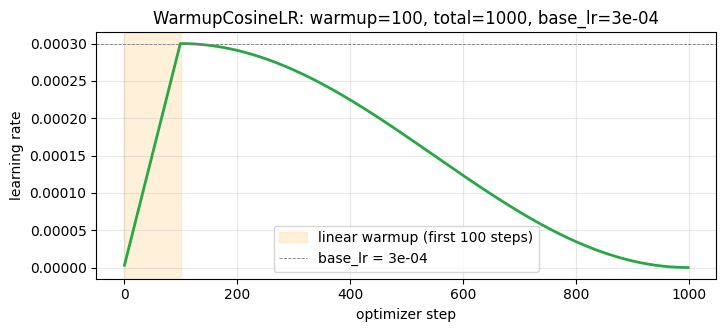

lr[0]            = 3.00e-06    (just stepped from 0)
lr[warmup]       = 3.00e-04    (peak, end of warmup)
lr[mid]          = 1.76e-04
lr[end]          = 0.00e+00    (near zero)


In [8]:
from lr_scheduler import WarmupCosineLR

class DummyOpt:
    def __init__(self, lr=0.0):
        self.param_groups = [{"lr": lr}]

base_lr = 3e-4
total = 1000
warmup = 100

opt = DummyOpt(0.0)
sched = WarmupCosineLR(opt, warmup_steps=warmup, total_steps=total, base_lr=base_lr)
lrs = [sched.step() for _ in range(total)]

fig, ax = plt.subplots(figsize=(8, 3.2))
ax.plot(lrs, lw=2, color="#28a745")
ax.axvspan(0, warmup, alpha=0.15, color="orange", label=f"linear warmup (first {warmup} steps)")
ax.axhline(base_lr, ls="--", lw=0.6, color="grey", label=f"base_lr = {base_lr:.0e}")
ax.set_xlabel("optimizer step")
ax.set_ylabel("learning rate")
ax.set_title(f"WarmupCosineLR: warmup={warmup}, total={total}, base_lr={base_lr:.0e}")
ax.legend(); ax.grid(alpha=0.3); plt.show()

print(f"lr[0]            = {lrs[0]:.2e}    (just stepped from 0)")
print(f"lr[warmup]       = {lrs[warmup-1]:.2e}    (peak, end of warmup)")
print(f"lr[mid]          = {lrs[total//2]:.2e}")
print(f"lr[end]          = {lrs[-1]:.2e}    (near zero)")


### Check two points by hand

Halfway through the warm-up (`step = 50` of `100`), the nudge should be halfway up to its peak:

$$\text{nudge}(50) = 3 \times 10^{-4} \cdot \frac{50}{100} = 1.5 \times 10^{-4} \quad (\text{half of the peak})$$

Halfway through the cool-down (`step = 550`), the smooth curve sits at exactly half the peak again:

$$\text{nudge}(550) = \tfrac{1}{2} \cdot 3 \times 10^{-4} \cdot (1 + \cos(\tfrac{\pi}{2})) = 1.5 \times 10^{-4}$$

Let's confirm both against the code:


In [9]:
print("step  50 lr =", lrs[49],   "   manual:", base_lr * 50/warmup)
print("step 550 lr =", lrs[549],  "   manual:", 0.5 * base_lr * (1 + math.cos(math.pi * 0.5)))


step  50 lr = 0.00015    manual: 0.00015
step 550 lr = 0.00015    manual: 0.00015


---
## 4.3 AMP (mixed precision) + Gradient Accumulation

```mermaid
graph TD
    raw["raw text file<br>(tiny.txt)"]
    bpe["4.1 BPE Tokenizer<br>train + encode/decode"]
    ds["4.1 Dataset / DataLoader<br>(x, y) shifted batches"]
    fwd["forward: GPTModern (Part 3)"]
    loss["CE loss"]
    amp["4.3 AMP + grad accum<br>scaled backward"]
    opt["AdamW step<br>(β = 0.9, 0.95; wd = 0.1)"]
    sched["4.2 Warmup + Cosine LR"]
    log["4.5 Logger<br>(TB / wandb / noop)"]
    ckpt["4.4 Checkpoint<br>model + opt + sched + scaler + step + cfg"]

    raw --> bpe --> ds --> fwd --> loss --> amp --> opt --> sched --> log --> ckpt
    ckpt -. next batch .-> fwd

    style raw fill:#e8e8e8,stroke:#bbb,color:#777
    style bpe fill:#e8e8e8,stroke:#bbb,color:#777
    style ds fill:#e8e8e8,stroke:#bbb,color:#777
    style fwd fill:#e8e8e8,stroke:#bbb,color:#777
    style loss fill:#e8e8e8,stroke:#bbb,color:#777
    style amp fill:#d5f5e3,stroke:#28a745,stroke-width:3px,color:#000
    style opt fill:#e8e8e8,stroke:#bbb,color:#777
    style sched fill:#e8e8e8,stroke:#bbb,color:#777
    style log fill:#e8e8e8,stroke:#bbb,color:#777
    style ckpt fill:#e8e8e8,stroke:#bbb,color:#777
```

This section is really two separate money-and-time-saving tricks that happen to live in the same helper. Take them one at a time.

### Part A — Fast rough arithmetic (mixed precision / AMP)

#### What we're doing here, and why

Numbers on a computer come in two flavours: **precise but slow** (lots of decimal places) and **rough but fast** (fewer decimal places, half the memory). Doing the math in the *rough* format runs about twice as fast and frees up a ton of memory — a huge win for big models.

But there's a catch, exactly like rounding money to the nearest dollar: a correction of **$0.003** rounds down to **$0** and vanishes. Many of the model's corrections are that tiny, and if they round to zero the model stops learning from them.

#### The fix: scale up, then scale back down

Simple trick. **Before** measuring the corrections, multiply everything by a big number (say 1000) so the tiny $0.003 becomes a comfortable $3 that survives the rounding. **After** computing them, divide by that same 1000 to get the true sizes back. Nothing is distorted — we just temporarily worked in "thousands" so the small values didn't disappear.

And it's self-adjusting: if the multiplier is ever *too* big and a number overflows, the helper notices, throws that step away, and uses a smaller multiplier next time. That auto-tuning multiplier is the whole job of the "GradScaler."

#### See the rounding-to-zero problem


In [10]:
# Show what happens to a tiny gradient when stored in fp16
small_grad = torch.tensor(1e-7, dtype=torch.float32)
small_grad_fp16 = small_grad.half()
print(f"fp32  : {small_grad.item():.3e}")
print(f"fp16  : {small_grad_fp16.item():.3e}   <- underflowed to 0!")
print()

scale = 1024.0
scaled = (small_grad * scale).half()
unscaled = scaled.float() / scale
print(f"With scaler (S=1024):")
print(f"  scale loss  -> {scaled.item():.3e}    (survives fp16)")
print(f"  unscale grad -> {unscaled.item():.3e}  (recovered original)")


fp32  : 1.000e-07
fp16  : 1.192e-07   <- underflowed to 0!

With scaler (S=1024):
  scale loss  -> 1.024e-04    (survives fp16)
  unscale grad -> 1.000e-07  (recovered original)


### Part B — Review a few, then update (gradient accumulation)

#### What we're doing here, and why

Bigger flashcard stacks give a steadier, more reliable correction — but a big stack might not fit in the GPU's memory at once. The workaround is exactly what you'd do studying at a small desk:

> You want to review 64 cards before updating your notes, but only 16 fit on your desk. So you go through 16, **jot the running tally on a scratchpad**, clear the desk, do the next 16, add to the tally... after 4 rounds your scratchpad holds the combined result of all 64 — and *then* you update your notes once.

That's gradient accumulation: do several small batches, keep adding up their corrections without applying them yet, and only nudge the weights after the last one. The result is identical to one big batch, just gentler on memory.

#### One small bookkeeping detail

Each small batch reports an *average* correction. If you simply add 4 averages together you'd get something 4× too big — like averaging four quiz scores by adding them but forgetting to divide. The fix is one line: divide each batch's correction by the number of batches before adding it.

```python
loss = loss / self.accum   # so 4 small batches add up to exactly one big-batch correction
```

#### Prove it: small batches add up to the big one


In [11]:
from amp_accum import AmpGrad

torch.manual_seed(0)
# Two tiny linear models with the same init
model_big   = nn.Linear(8, 4)
model_accum = nn.Linear(8, 4)
model_accum.load_state_dict(model_big.state_dict())

# One big batch of 16
x_big = torch.randn(16, 8); y_big = torch.randn(16, 4)
loss_big = F.mse_loss(model_big(x_big), y_big)
loss_big.backward()
grad_big = model_big.weight.grad.clone()

# Four micro-batches of 4
opt_a = torch.optim.SGD(model_accum.parameters(), lr=0.0)
amp = AmpGrad(opt_a, accum=4, amp=False)
for k in range(4):
    xs = x_big[k*4:(k+1)*4]; ys = y_big[k*4:(k+1)*4]
    loss = F.mse_loss(model_accum(xs), ys)
    amp.backward(loss)
grad_accum = model_accum.weight.grad.clone()

print(f"max abs diff between gradients: {(grad_big - grad_accum).abs().max().item():.3e}")
print("(They should match to ~1e-7 — accumulated micro-batches reproduce the big-batch gradient.)")


max abs diff between gradients: 5.960e-08
(They should match to ~1e-7 — accumulated micro-batches reproduce the big-batch gradient.)


C:\Home\Projects\DataScienceLearningProjects\15. Build LLM From Scratch\part_4\amp_accum.py:75: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = torch.cuda.amp.GradScaler(enabled=self.amp)


### Both tricks, one helper

The `AmpGrad` wrapper bundles both ideas so the training loop stays tidy — fast arithmetic *and* "review a few, then update" in one place:

```python
amp = AmpGrad(optimizer, accum=4, amp=True)

# inside the training loop:
with torch.cuda.amp.autocast(enabled=amp.amp):   # do the math in the fast rough format
    logits, loss, _ = model(xb, yb)
amp.backward(loss)            # scale up tiny values, divide by accum, add to the tally

if amp.should_step():         # only every 4 small batches...
    amp.step()                # ...actually nudge the weights
    amp.zero_grad()           # wipe the scratchpad for the next round
    lr = scheduler.step()     # and adjust the nudge size (section 4.2)
```


---
## 4.4 Saving Your Progress (Checkpointing)

```mermaid
graph TD
    raw["raw text file<br>(tiny.txt)"]
    bpe["4.1 BPE Tokenizer<br>train + encode/decode"]
    ds["4.1 Dataset / DataLoader<br>(x, y) shifted batches"]
    fwd["forward: GPTModern (Part 3)"]
    loss["CE loss"]
    amp["4.3 AMP + grad accum<br>scaled backward"]
    opt["AdamW step<br>(β = 0.9, 0.95; wd = 0.1)"]
    sched["4.2 Warmup + Cosine LR"]
    log["4.5 Logger<br>(TB / wandb / noop)"]
    ckpt["4.4 Checkpoint<br>model + opt + sched + scaler + step + cfg"]

    raw --> bpe --> ds --> fwd --> loss --> amp --> opt --> sched --> log --> ckpt
    ckpt -. next batch .-> fwd

    style raw fill:#e8e8e8,stroke:#bbb,color:#777
    style bpe fill:#e8e8e8,stroke:#bbb,color:#777
    style ds fill:#e8e8e8,stroke:#bbb,color:#777
    style fwd fill:#e8e8e8,stroke:#bbb,color:#777
    style loss fill:#e8e8e8,stroke:#bbb,color:#777
    style amp fill:#e8e8e8,stroke:#bbb,color:#777
    style opt fill:#e8e8e8,stroke:#bbb,color:#777
    style sched fill:#e8e8e8,stroke:#bbb,color:#777
    style log fill:#e8e8e8,stroke:#bbb,color:#777
    style ckpt fill:#d5f5e3,stroke:#28a745,stroke-width:3px,color:#000
```

### What we're doing here, and why

Real training runs for hours or days. Power cuts happen, you need the machine back, things crash. Just like a long video game, you need a **save point** so you don't start over from zero. A good save lets you reload and continue *as if nothing happened*.

But here's the subtle part: saving only the model's weights isn't enough. To truly continue mid-session you also need the **coach's notes** — which step you were on, how big the nudges currently are, the auto-tuning multiplier from 4.3. Reload all of it and the run picks up seamlessly; reload only the weights and you'd restart the warm-up and lose momentum.

### What we tuck into the save file

| Saved item | Why you need it to resume |
|---|---|
| the model weights | the actual thing you trained |
| the optimizer state | its "momentum" — which way it was already pushing |
| the schedule position | so the nudge size continues mid-curve, not from the start |
| the AMP multiplier | so the fast-math trick doesn't re-tune from scratch |
| the step number | so counters and the progress chart line up |
| the model's blueprint (`config`) | so we can rebuild the *exact* same model — see the guard below |

We also drop a little note next to the save file recording *which tokenizer* was used, so the exam script (4.7) and any resumed run can find the matching chunker.

### Let's save a tiny model and load it back


In [12]:
from checkpointing import save_checkpoint, load_checkpoint
from lr_scheduler import WarmupCosineLR
from amp_accum import AmpGrad
from model_modern import GPTModern

# Build a tiny GPTModern
def build_tiny():
    return GPTModern(vocab_size=tok.vocab_size, block_size=32, n_layer=2,
                     n_head=4, n_embd=64, n_kv_head=2, use_rmsnorm=True,
                     use_swiglu=True, rope=True, max_pos=128)

torch.manual_seed(0)
m   = build_tiny()
opt = torch.optim.AdamW(m.parameters(), lr=3e-4, betas=(0.9, 0.95), weight_decay=0.1)
sch = WarmupCosineLR(opt, warmup_steps=10, total_steps=100, base_lr=3e-4)
amp = AmpGrad(opt, accum=2, amp=False)

# Pretend we trained a few steps
for _ in range(7):
    sch.step()
fake_step = 7

# Save
out_dir = pathlib.Path(tmp) / "ckpt"
save_checkpoint(m, opt, sch, amp, step=fake_step, out_dir=str(out_dir),
                tokenizer_dir=str(tok_dir), config=None)
print("Files in checkpoint dir:")
for p in sorted(out_dir.iterdir()):
    print(f"  {p.name}   ({p.stat().st_size:,} bytes)")


Files in checkpoint dir:
  model_last.pt   (757,173 bytes)
  tokenizer_dir.txt   (47 bytes)


### What's actually in the save file?

Let's open it up and look at everything that got tucked away — weights, coach's notes, step number, and the model's blueprint.


In [13]:
ckpt = torch.load(out_dir / "model_last.pt", map_location="cpu", weights_only=False)
print("Top-level keys in model_last.pt:")
for k, v in ckpt.items():
    if k == "model":
        print(f"  {k:12s} : dict with {len(v)} tensors (state_dict)")
    elif k == "config":
        print(f"  {k:12s} : {v}")
    elif isinstance(v, dict):
        print(f"  {k:12s} : dict with keys {list(v.keys())}")
    else:
        print(f"  {k:12s} : {v!r}")


Top-level keys in model_last.pt:
  model        : dict with 20 tensors (state_dict)
  optimizer    : dict with keys ['state', 'param_groups']
  scheduler    : None
  amp_scaler   : dict with keys []
  step         : 7
  config       : {'vocab_size': 500, 'block_size': 32, 'n_layer': 2, 'n_head': 4, 'n_embd': 64, 'n_kv_head': 2, 'dropout': 0.0, 'use_rmsnorm': True, 'use_swiglu': True, 'max_pos': 128, 'sliding_window': None, 'attention_sink': 0}
  version      : 'part4-v2'


### Load it into a brand-new model and check it matches

Now the real test: build a fresh, untrained model, load the save into it, and confirm every weight comes back *bit-for-bit identical* — proof that "resume" really does continue exactly where we left off.


In [14]:
# Build a fresh model with the SAME architecture and load
m2 = build_tiny()
opt2 = torch.optim.AdamW(m2.parameters(), lr=3e-4, betas=(0.9, 0.95), weight_decay=0.1)
sch2 = WarmupCosineLR(opt2, warmup_steps=10, total_steps=100, base_lr=3e-4)
amp2 = AmpGrad(opt2, accum=2, amp=False)

restored_step = load_checkpoint(m2, str(out_dir / "model_last.pt"),
                                optimizer=opt2, scheduler=sch2, amp=amp2, strict=True)
print(f"Restored step: {restored_step}")

# Check weights match exactly
all_match = all(torch.equal(p1, p2) for p1, p2 in zip(m.parameters(), m2.parameters()))
print(f"All parameters identical after round-trip? {all_match}")


Restored step: 7
All parameters identical after round-trip? True


### The safety check: don't load into the wrong model

What if you accidentally try to load a save into a model of the *wrong shape* — say a 4-layer model when the save came from a 2-layer one? That's like restoring a saved game into the wrong game entirely. Rather than half-loading and producing silent nonsense, the loader compares the saved blueprint against the new model and **refuses with a clear error**. Let's trigger it on purpose:


In [15]:
# Build a model with a mismatched architecture (n_layer=4 instead of 2)
m_wrong = GPTModern(vocab_size=tok.vocab_size, block_size=32, n_layer=4,   # <-- changed
                    n_head=4, n_embd=64, n_kv_head=2, use_rmsnorm=True,
                    use_swiglu=True, rope=True, max_pos=128)

try:
    load_checkpoint(m_wrong, str(out_dir / "model_last.pt"), strict=True)
    print("(unexpected) load succeeded")
except RuntimeError as e:
    print("PASS - raised:", str(e).splitlines()[0])
    for line in str(e).splitlines()[1:5]:
        print("       ", line)


PASS - raised: Architecture mismatch:
          n_layer: ckpt=2 vs model=4
        Rebuild the model with this config, or load with strict=False.


---
## 4.5 The Progress Chart (Logging)

```mermaid
graph TD
    raw["raw text file<br>(tiny.txt)"]
    bpe["4.1 BPE Tokenizer<br>train + encode/decode"]
    ds["4.1 Dataset / DataLoader<br>(x, y) shifted batches"]
    fwd["forward: GPTModern (Part 3)"]
    loss["CE loss"]
    amp["4.3 AMP + grad accum<br>scaled backward"]
    opt["AdamW step<br>(β = 0.9, 0.95; wd = 0.1)"]
    sched["4.2 Warmup + Cosine LR"]
    log["4.5 Logger<br>(TB / wandb / noop)"]
    ckpt["4.4 Checkpoint<br>model + opt + sched + scaler + step + cfg"]

    raw --> bpe --> ds --> fwd --> loss --> amp --> opt --> sched --> log --> ckpt
    ckpt -. next batch .-> fwd

    style raw fill:#e8e8e8,stroke:#bbb,color:#777
    style bpe fill:#e8e8e8,stroke:#bbb,color:#777
    style ds fill:#e8e8e8,stroke:#bbb,color:#777
    style fwd fill:#e8e8e8,stroke:#bbb,color:#777
    style loss fill:#e8e8e8,stroke:#bbb,color:#777
    style amp fill:#e8e8e8,stroke:#bbb,color:#777
    style opt fill:#e8e8e8,stroke:#bbb,color:#777
    style sched fill:#e8e8e8,stroke:#bbb,color:#777
    style log fill:#d5f5e3,stroke:#28a745,stroke-width:3px,color:#000
    style ckpt fill:#e8e8e8,stroke:#bbb,color:#777
```

### What we're doing here, and why

When training runs for hours, you can't just stare at it. You want a **chart on the wall** — like a fitness tracker — showing the loss dropping, the nudge size following its curve, how fast you're going, even a sample of the model's writing. Watching those lines is how you catch problems early (loss flat? loss exploding?) instead of discovering them a day later.

This is called **logging**, and the most common tool is **TensorBoard** (a little web dashboard). Part 4 offers three interchangeable options behind one simple `logger.log(...)` call, so the training loop never has to care which one is plugged in:

- **NoopLogger** — a do-nothing stand-in (when you don't want any chart)
- **TBLogger** — writes to TensorBoard
- **WBLogger** — sends to Weights & Biases (a hosted version of the same idea)

The neat part: you call `logger.log(step=..., loss=..., lr=...)` the same way every time, and the logger figures out on its own whether each value is a single number to plot as a line, or a whole bundle of numbers to show as a distribution. So one simple call handles everything. Let's write a few fake values to a chart:


In [16]:
from logger import init_logger, NoopLogger, TBLogger

log_dir = pathlib.Path(tmp) / "tblogs"
log_dir.mkdir(parents=True, exist_ok=True)

# Try TBLogger; fall back to NoopLogger if tensorboard isn't available
logger = init_logger("tensorboard", out_dir=str(log_dir))
print(f"Logger type: {type(logger).__name__}")

# Log a few synthetic values
for step in range(5):
    logger.log(
        step=step,
        loss=2.5 * 0.9 ** step,           # scalar
        lr=3e-4 * step / 4,                # scalar
        **{"sys/throughput_tokens_per_s": 1000.0 + 50 * step},
    )
    # log a histogram via the hist helper
    if hasattr(logger, "hist"):
        logger.hist("debug/random_tensor", torch.randn(256), step)
    # log a sample text
    if hasattr(logger, "text"):
        logger.text("samples/dummy", f"step {step}: hello world", step)

if hasattr(logger, "flush"):
    logger.flush()

if hasattr(logger, "run_dir"):
    print(f"Wrote TB events under: {logger.run_dir}")
    print("Inspect with:  tensorboard --logdir", str(log_dir))


[TBLogger] TensorBoard not available: No module named 'tensorboard'. Logging disabled.
Logger type: NoopLogger


**To actually see the chart**, you'd run this in a terminal and open the link it prints:

```bash
tensorboard --logdir <log_dir>
```

Then open `http://localhost:6006/` in your browser — that's the live dashboard your training run draws on.


---
## 4.6 One Full Study Session (the Training Loop)

```mermaid
graph TD
    raw["raw text file<br>(tiny.txt)"]
    bpe["4.1 BPE Tokenizer<br>train + encode/decode"]
    ds["4.1 Dataset / DataLoader<br>(x, y) shifted batches"]
    fwd["forward: GPTModern (Part 3)"]
    loss["CE loss"]
    amp["4.3 AMP + grad accum<br>scaled backward"]
    opt["AdamW step<br>(β = 0.9, 0.95; wd = 0.1)"]
    sched["4.2 Warmup + Cosine LR"]
    log["4.5 Logger<br>(TB / wandb / noop)"]
    ckpt["4.4 Checkpoint<br>model + opt + sched + scaler + step + cfg"]

    raw --> bpe --> ds --> fwd --> loss --> amp --> opt --> sched --> log --> ckpt
    ckpt -. next batch .-> fwd

    style raw fill:#d5f5e3,stroke:#28a745,stroke-width:3px,color:#000
    style bpe fill:#d5f5e3,stroke:#28a745,stroke-width:3px,color:#000
    style ds fill:#d5f5e3,stroke:#28a745,stroke-width:3px,color:#000
    style fwd fill:#d5f5e3,stroke:#28a745,stroke-width:3px,color:#000
    style loss fill:#d5f5e3,stroke:#28a745,stroke-width:3px,color:#000
    style amp fill:#d5f5e3,stroke:#28a745,stroke-width:3px,color:#000
    style opt fill:#d5f5e3,stroke:#28a745,stroke-width:3px,color:#000
    style sched fill:#d5f5e3,stroke:#28a745,stroke-width:3px,color:#000
    style log fill:#d5f5e3,stroke:#28a745,stroke-width:3px,color:#000
    style ckpt fill:#d5f5e3,stroke:#28a745,stroke-width:3px,color:#000
```

### What we're doing here, and why

Time to put the whole study session together. Everything from 4.1-4.5 happens in one repeating rhythm: **deal a stack of flashcards → let the model guess → measure how wrong → work out the correction → (every few stacks) nudge the weights → adjust the nudge size → jot it on the chart.** Below is exactly that, one step at a time, in the same order the real `train.py` runs it.

### The guess → grade → correct rhythm


In [17]:
# Build a tiny model + optimizer + scheduler + amp + logger from scratch.
torch.manual_seed(0)
device = torch.device("cpu")   # works everywhere; train.py picks cuda if available
model = build_tiny().to(device)
optim = torch.optim.AdamW(model.parameters(), lr=3e-4, betas=(0.9, 0.95), weight_decay=0.1)
sched = WarmupCosineLR(optim, warmup_steps=10, total_steps=100, base_lr=3e-4)
amp   = AmpGrad(optim, accum=2, amp=False)    # CPU here -> turn AMP off
logger = NoopLogger()                          # silent for the walkthrough

train_loader = make_loader(str(data_path), tok, block_size=block_size, batch_size=4, shuffle=True)
print(f"Model params      : {sum(p.numel() for p in model.parameters()):,}")
print(f"Loader length     : {len(train_loader)} batches")


Model params      : 187,136
Loader length     : 746 batches


In [18]:
model.train()
step = 0
losses = []

# Two micro-batches per optimizer step (accum=2)
for micro, (xb, yb) in enumerate(train_loader):
    xb, yb = xb.to(device), yb.to(device)

    # 1) forward + CE loss
    logits, loss, _ = model(xb, yb)
    losses.append(loss.item())

    # 2) scaled backward + accumulate
    amp.backward(loss)

    print(f"micro {micro}: loss={loss.item():.4f}  should_step={amp.should_step()}")

    # 3) every `accum` micro-batches, take a real optimizer step
    if amp.should_step():
        amp.step()
        amp.zero_grad()
        lr = sched.step()
        step += 1
        logger.log(step=step, loss=loss.item(), lr=lr)
        print(f"  -> stepped: step={step}, lr={lr:.6f}")

    if step >= 2:
        break


micro 0: loss=6.5729  should_step=False
micro 1: loss=6.5349  should_step=True
  -> stepped: step=1, lr=0.000030
micro 2: loss=6.4876  should_step=False
micro 3: loss=6.4619  should_step=True
  -> stepped: step=2, lr=0.000060


### What just happened — in plain words

| The line | What it did, in coaching terms |
|---|---|
| `make_loader(...)` | chopped the text and made flashcard stacks (4 cards each, 12 pieces wide) |
| `xb, yb = batch` | one stack: the front of the cards (`xb`) and their answers (`yb`, shifted by one) |
| `model(xb, yb)` | the model guessed, and we measured how wrong (`loss`) |
| `amp.backward(loss)` | worked out the correction and added it to the scratchpad tally |
| `amp.should_step()` | "have we reviewed enough cards yet?" — true every 2 stacks |
| `amp.step()` | actually nudged the weights |
| `amp.zero_grad()` | wiped the scratchpad for the next round |
| `sched.step()` | adjusted the nudge size along its gentle → bold → gentle curve |
| `logger.log(...)` | added a dot to the progress chart |

The real `train.py` wraps this same rhythm with a few grown-up extras:
  * an outer loop that keeps going until the target number of steps
  * **auto-saving** progress every so often (section 4.4)
  * a **graceful Ctrl-C**: if you stop it, it saves one last time before exiting, so you never lose work
  * richer chart entries (speed, internal health stats)


---
## 4.7 The Exam (Sampling)

```mermaid
graph TD
    raw["raw text file<br>(tiny.txt)"]
    bpe["4.1 BPE Tokenizer<br>train + encode/decode"]
    ds["4.1 Dataset / DataLoader<br>(x, y) shifted batches"]
    fwd["forward: GPTModern (Part 3)"]
    loss["CE loss"]
    amp["4.3 AMP + grad accum<br>scaled backward"]
    opt["AdamW step<br>(β = 0.9, 0.95; wd = 0.1)"]
    sched["4.2 Warmup + Cosine LR"]
    log["4.5 Logger<br>(TB / wandb / noop)"]
    ckpt["4.4 Checkpoint<br>model + opt + sched + scaler + step + cfg"]

    raw --> bpe --> ds --> fwd --> loss --> amp --> opt --> sched --> log --> ckpt
    ckpt -. next batch .-> fwd

    style raw fill:#e8e8e8,stroke:#bbb,color:#777
    style bpe fill:#e8e8e8,stroke:#bbb,color:#777
    style ds fill:#e8e8e8,stroke:#bbb,color:#777
    style fwd fill:#e8e8e8,stroke:#bbb,color:#777
    style loss fill:#e8e8e8,stroke:#bbb,color:#777
    style amp fill:#e8e8e8,stroke:#bbb,color:#777
    style opt fill:#e8e8e8,stroke:#bbb,color:#777
    style sched fill:#e8e8e8,stroke:#bbb,color:#777
    style log fill:#e8e8e8,stroke:#bbb,color:#777
    style ckpt fill:#d5f5e3,stroke:#28a745,stroke-width:3px,color:#000
```

### What we're doing here, and why

Training is over; now the **exam**. `sample.py` does the reverse of training: open the save file, rebuild the exact model from its blueprint, load the matching chunker, hand the model a starting phrase, and let it write the next words *on its own* — no answer key. This is the moment you actually *use* what you trained.

It's just the pieces we've already seen, chained together:

```python
ckpt = torch.load(args.ckpt, map_location='cpu')   # open the save
cfg = ckpt.get('config')                            # read the blueprint
model = GPTModern(**cfg).eval()                     # rebuild the exact model
model.load_state_dict(ckpt['model'])                # pour the weights back in

tok = BPETokenizer(); tok.load(<path from the note>) # load the matching chunker

ids = tok.encode(args.prompt) or [10]               # turn the prompt into pieces
out = model.generate(torch.tensor([ids]), max_new_tokens=args.tokens)  # write!
print(tok.decode(out[0].tolist()))                  # turn pieces back into text
```

### Let's give our saved model the exam


In [19]:
# Use the checkpoint we saved in 4.4
ckpt_path = out_dir / "model_last.pt"
ck = torch.load(ckpt_path, map_location="cpu", weights_only=False)

m_sample = GPTModern(**ck['config']).eval()
m_sample.load_state_dict(ck['model'])

# Encode the anchor sentence beginning as a prompt
prompt_ids = tok.encode("i love")
print(f"Prompt: 'i love'  -> ids = {prompt_ids}")
prompt = torch.tensor([prompt_ids], dtype=torch.long)

with torch.no_grad():
    out = m_sample.generate(prompt, max_new_tokens=30, temperature=1.0, top_k=50)
ids = out[0].tolist()
print(f"\nGenerated ids ({len(ids)}): {ids}")
print(f"Decoded text   : {tok.decode(ids)!r}")


Prompt: 'i love'  -> ids = [77, 280]

Generated ids (32): [77, 280, 214, 270, 467, 336, 41, 239, 268, 312, 381, 380, 41, 436, 128, 169, 28, 448, 8, 322, 386, 24, 272, 372, 386, 309, 34, 157, 134, 202, 294, 320]
Decoded text   : 'i love\x15ningE�epE��8$4 i>��\t'


(The output is gibberish — and that's completely expected. Our model never actually studied; we only wired up the machinery. A real model trained on real text would write something sensible. We're checking that the *plumbing* works end to end, not that the student is smart yet.)

### Tidy up


In [20]:
# Clean up the tempdir
try:
    shutil.rmtree(tmp)
    print(f"Removed temp dir {tmp}")
except Exception as e:
    print(f"(could not delete tempdir: {e})")


Removed temp dir C:\Users\MSI\AppData\Local\Temp\tmp0c8dt2o8


---
## Closing the loop

```mermaid
graph TD
    raw["raw text file<br>(tiny.txt)"]
    bpe["4.1 BPE Tokenizer<br>train + encode/decode"]
    ds["4.1 Dataset / DataLoader<br>(x, y) shifted batches"]
    fwd["forward: GPTModern (Part 3)"]
    loss["CE loss"]
    amp["4.3 AMP + grad accum<br>scaled backward"]
    opt["AdamW step<br>(β = 0.9, 0.95; wd = 0.1)"]
    sched["4.2 Warmup + Cosine LR"]
    log["4.5 Logger<br>(TB / wandb / noop)"]
    ckpt["4.4 Checkpoint<br>model + opt + sched + scaler + step + cfg"]

    raw --> bpe --> ds --> fwd --> loss --> amp --> opt --> sched --> log --> ckpt
    ckpt -. next batch .-> fwd

    style raw fill:#d5f5e3,stroke:#28a745,stroke-width:3px,color:#000
    style bpe fill:#d5f5e3,stroke:#28a745,stroke-width:3px,color:#000
    style ds fill:#d5f5e3,stroke:#28a745,stroke-width:3px,color:#000
    style fwd fill:#d5f5e3,stroke:#28a745,stroke-width:3px,color:#000
    style loss fill:#d5f5e3,stroke:#28a745,stroke-width:3px,color:#000
    style amp fill:#d5f5e3,stroke:#28a745,stroke-width:3px,color:#000
    style opt fill:#d5f5e3,stroke:#28a745,stroke-width:3px,color:#000
    style sched fill:#d5f5e3,stroke:#28a745,stroke-width:3px,color:#000
    style log fill:#d5f5e3,stroke:#28a745,stroke-width:3px,color:#000
    style ckpt fill:#d5f5e3,stroke:#28a745,stroke-width:3px,color:#000
```

### The whole study session, in one breath

- **4.1 Read in chunks** — turn text into meaningful pieces, then into flashcards (front = words, back = the next word).
- **4.2 Correction size** — nudge gently at first, boldly in the middle, gently again at the end.
- **4.3 Work smart** — do the math fast and rough (scaling tiny values so they survive), and review a few stacks before each nudge.
- **4.4 Save progress** — store weights *and* the coach's notes so you can resume exactly; refuse to load into the wrong model.
- **4.5 Progress chart** — log loss and friends to a live dashboard.
- **4.6 The session** — the repeating guess → grade → correct → record rhythm.
- **4.7 The exam** — give a saved model a prompt and let it write.

You now have everything needed to read every file in `part_4/`:

- [tokenizer_bpe.py](tokenizer_bpe.py) — section 4.1 (reading in chunks)
- [dataset_bpe.py](dataset_bpe.py) — section 4.1 (the flashcards)
- [lr_scheduler.py](lr_scheduler.py) — section 4.2 (correction size)
- [amp_accum.py](amp_accum.py) — section 4.3 (fast math + review-then-update)
- [checkpointing.py](checkpointing.py) — section 4.4 (save & resume)
- [logger.py](logger.py) — section 4.5 (the progress chart)
- [train.py](train.py) — section 4.6 (the full study session, plus safe Ctrl-C)
- [sample.py](sample.py) — section 4.7 (the exam)

**The one-line takeaway:** training is just *guess the next word → see how wrong → make a small correction*, repeated millions of times — and everything in Part 4 is one practical detail that makes that loop fast, stable, and resumable.

### What's next

Part 5 swaps the model's single feed-forward for a **Mixture of Experts** — a little team of specialist sub-networks with a receptionist that routes each word to the right ones. The training recipe from this part carries straight over. Parts 6-9 (the alignment arc) all build on a **trained Part 4 tokenizer + base model**, so at some point run:

    cd part_4
    python orchestrator.py --demo
